In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
nav = pd.read_csv("../1.data/processed/nav_history_cleaned.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
print("Shape:", nav.shape)
print("Funds:", nav['amfi_code'].nunique())
print(nav['daily_return'].describe())

Shape: (46000, 4)
Funds: 40
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [4]:
var_results = []

for fund in nav['amfi_code'].unique():
    r = nav[nav['amfi_code'] == fund]['daily_return'].dropna()

    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()

    var_results.append([fund, var_95, cvar_95])

var_df = pd.DataFrame(var_results, columns=[
    "amfi_code", "VaR_95", "CVaR_95"
])

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_df.to_csv("../5.reports/var_cvar_report.csv", index=False)

print("VaR CVaR report saved")

VaR CVaR report saved


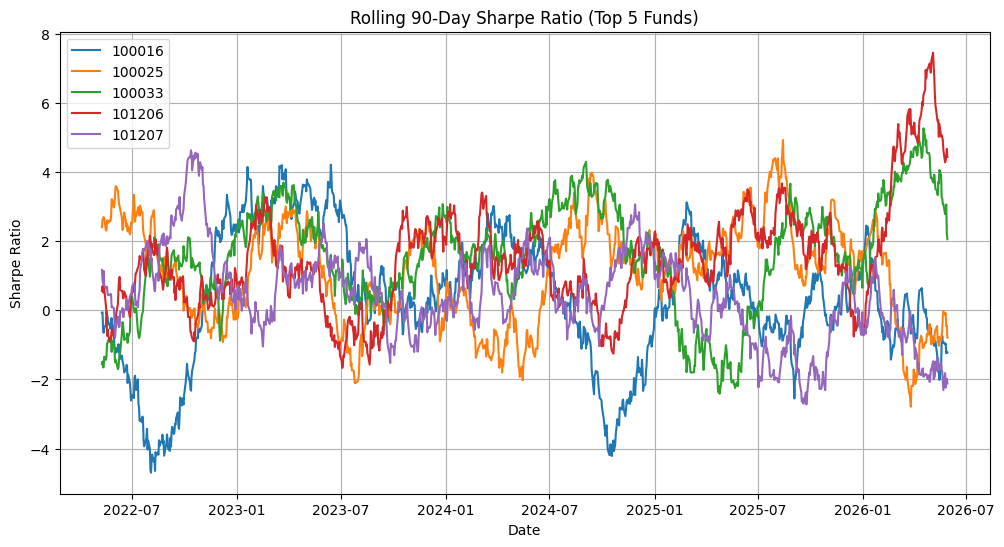

In [6]:
import numpy as np
import matplotlib.pyplot as plt

top5 = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for f in top5:
    temp = nav[nav['amfi_code'] == f].copy()
    r = temp['daily_return']

    rolling_sharpe = (
        r.rolling(90).mean() / r.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(temp['date'], rolling_sharpe, label=str(f))

plt.title("Rolling 90-Day Sharpe Ratio (Top 5 Funds)")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid()
plt.show()

In [7]:
plt.savefig("../5.reports/rolling_sharpe_chart.png", bbox_inches='tight')
print("Rolling Sharpe chart saved")

Rolling Sharpe chart saved


<Figure size 640x480 with 0 Axes>

In [8]:
txn = pd.read_csv("../1.data/raw/08_investor_transactions.csv")
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

txn['cohort_year'] = txn.groupby('investor_id')['transaction_date'].transform('min').dt.year

cohort_summary = txn.groupby('cohort_year')['amount_inr'].agg(['mean','sum','count'])

cohort_summary

,mean,sum,count
cohort_year,,,
2024,107422.541832,3491125187,32499
2025,109158.577061,30455243,279


In [9]:
txn = txn.sort_values(['investor_id', 'transaction_date'])

txn['gap_days'] = txn.groupby('investor_id')['transaction_date'].diff().dt.days

at_risk = txn[txn['gap_days'] > 35]

print("At-risk investors:", at_risk['investor_id'].nunique())

At-risk investors: 4527


In [10]:
performance = pd.read_csv("../1.data/processed/scheme_performance_cleaned.csv")

def recommend(risk_level):
    df = performance[performance['risk_grade'] == risk_level]
    df = df.sort_values('sharpe_ratio', ascending=False)
    return df[['scheme_name','sharpe_ratio']].head(3)

recommend("High")

,scheme_name,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,0.95
38,DSP Midcap Fund - Regular - Growth,0.90


In [11]:
portfolio = pd.read_csv("../1.data/raw/09_portfolio_holdings.csv")

hhi = portfolio.groupby('amfi_code')['weight_pct'].apply(
    lambda x: (x/100)**2
).groupby(level=0).sum()

hhi.head()

amfi_code
100016    0.139534
100033    0.147592
101206    0.129332
101207    0.200700
102885    0.174709
Name: weight_pct, dtype: float64

### Advanced Analytics Insights

1. Funds with high VaR indicate higher downside risk during market stress.
2. Rolling Sharpe shows stability differences between top-performing funds.
3. Older investor cohorts contribute higher total investment volume.
4. SIP gaps greater than 35 days indicate potential investor churn risk.
5. High HHI funds show concentrated sector exposure and higher risk.